# Binary Classification: Logistic Regression

In supervised learning, **binary classification** means the response variable has only two possible classes.

**Examples:**
- 0 = no default, 1 = default
- 0 = not spam, 1 = spam
- 0 = benign, 1 = malignant

In this lecture, we focus on **logistic regression**.

Unlike linear regression, which predicts a continuous value, logistic regression predicts a **probability** between 0 and 1.  
We then use that probability to decide whether an observation belongs to class 0 or class 1.

In our tumor example:
- 0 = benign
- 1 = malignant

So logistic regression helps answer this question:

> **What is the probability that a tumor is malignant, given its size?**

## Why Not Use Linear Regression?

Suppose we tried to use linear regression to predict whether a tumor is benign or malignant.

A linear regression model can produce values **less than 0 or greater than 1** — but probabilities must stay between 0 and 1.

The plot below shows the problem clearly: the straight line goes below 0 for small tumors and above 1 for large ones.

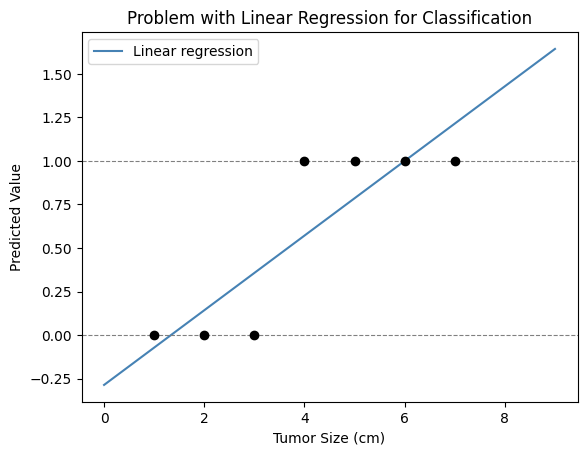

Predicted value for tumor size = 0.5 cm: -0.179
Predicted value for tumor size = 8.0 cm: 1.429


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

tumor_size_demo = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]).reshape(-1, 1)
diagnosis_demo  = np.array([0,   0,   0,   1,   1,   1,   1])

lin_model = LinearRegression()
lin_model.fit(tumor_size_demo, diagnosis_demo)

x_range = np.linspace(0, 9, 300).reshape(-1, 1)
y_line  = lin_model.predict(x_range)

plt.scatter(tumor_size_demo, diagnosis_demo, color='black', zorder=5)
plt.plot(x_range, y_line, color='steelblue', label='Linear regression')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Tumor Size (cm)')
plt.ylabel('Predicted Value')
plt.title('Problem with Linear Regression for Classification')
plt.legend()
plt.show()

print('Predicted value for tumor size = 0.5 cm:', round(lin_model.predict([[0.5]])[0], 3))
print('Predicted value for tumor size = 8.0 cm:', round(lin_model.predict([[8.0]])[0], 3))

The linear model predicts values outside the [0, 1] range, which cannot be interpreted as probabilities.  
This is why we use **logistic regression** for binary classification.

---
## The Sigmoid Function

The core of logistic regression is the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The input to the sigmoid function is a **score**:

$$z = \beta_0 + \beta_1 x$$

The output of the sigmoid function is a **probability**:

$$p = \sigma(z)$$

So logistic regression works in three steps:

1. Compute the score $z$
2. Apply the sigmoid function
3. Get the predicted probability $p$

The sigmoid function takes **any real number** and converts it into a value between 0 and 1.

**Key points:**
- If $z$ is very negative → output is close to **0**
- If $z$ is very positive → output is close to **1**
- If $z = 0$ → output is exactly **0.5**


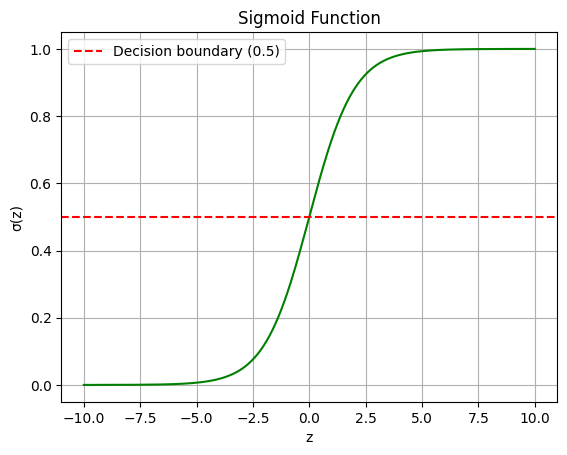

In [2]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.plot(z, sigmoid, color='green')
plt.axhline(y=0.5, linestyle='--', color='red', label='Decision boundary (0.5)')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Function')
plt.legend()
plt.grid(True)
plt.show()

---
## Logistic Regression Model

For one predictor $x$, logistic regression uses the following steps.

### Step 1: Learn the parameters from the training data

The model uses the **training data** to learn the values of $\beta_0$ and $\beta_1$.

- $\beta_0$ = intercept
- $\beta_1$ = coefficient for $x$

These are **parameters learned by the model**.  
They are different from **hyperparameters**, which are settings that we choose before training.

### Step 2: Compute the score

$$z = \beta_0 + \beta_1 x$$

This $z$ value is sometimes called the **score** or **linear predictor**.

### Step 3: Apply the sigmoid function

$$p = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Here $p$ is the predicted probability of class 1.

In our tumor example:
- $x$ = tumor size
- $p = P(\text{malignant} = 1 \mid x)$

So a larger tumor size can lead to a larger score $z$, which then leads to a larger predicted probability of malignancy.


### Simple Example: From Score $z$ to Probability $p$

Suppose the model learned these parameter values from the training data:

- $\beta_0 = -6$
- $\beta_1 = 1.5$

Then for a tumor of size $x$, we first compute the score

$$z = -6 + 1.5x$$

and then apply the sigmoid function

$$p = \frac{1}{1 + e^{-z}}$$

Here $p$ is the predicted probability that the tumor is **malignant**.


In [4]:
beta_0 = -6
beta_1 = 1.5
x = 3 #tumor size

z = beta_0 + beta_1 * x
p = 1 / (1 + np.exp(-z))
print("Tumor size =", x, "cm")
print("z =", beta_0, "+", beta_1, "*", x, "=", round(z, 3))
print("p =", round(p, 3))
print()

x= 4 #tumor size
z = beta_0 + beta_1 * x
p = 1 / (1 + np.exp(-z))
print("Tumor size =", x, "cm")
print("z =", beta_0, "+", beta_1, "*", x, "=", round(z, 3))
print("p =", round(p, 3))
print()

x= 5 #tumor size
z = beta_0 + beta_1 * x
p = 1 / (1 + np.exp(-z))
print("Tumor size =", x, "cm")
print("z =", beta_0, "+", beta_1, "*", x, "=", round(z, 3))
print("p =", round(p, 3))

Tumor size = 3 cm
z = -6 + 1.5 * 3 = -1.5
p = 0.182

Tumor size = 4 cm
z = -6 + 1.5 * 4 = 0.0
p = 0.5

Tumor size = 5 cm
z = -6 + 1.5 * 5 = 1.5
p = 0.818


In this simple example:

- For a tumor size of **3 cm**, the predicted probability of malignancy is about **0.18**
- For a tumor size of **4 cm**, the predicted probability is **0.50**
- For a tumor size of **5 cm**, the predicted probability rises to about **0.82**

This shows the idea clearly:

**tumor size $x$ → score $z$ → sigmoid → probability $p$**


---
## Loss Function: Binary Cross-Entropy

In regression, common loss functions are MSE, RMSE, and MAE.

For logistic regression, the standard loss function is **binary cross-entropy**, also called **log loss**:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

where:
- $y_i$ is the true class label (0 or 1)
- $\hat{p}_i$ is the predicted probability of class 1

For **one observation**, the loss is:

$$\text{Loss}_i = -\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

**Two important cases:**

| True label $y_i$ | Active loss term | Penalizes |
|---|---|---|
| $y_i = 1$ (malignant) | $-\log(\hat{p}_i)$ | Predicting a low probability for malignant |
| $y_i = 0$ (benign) | $-\log(1 - \hat{p}_i)$ | Predicting a high probability for malignant |

The model learns by **minimizing this loss** — pushing predicted probabilities closer to the true labels.


### Worked Example: Calculating Binary Cross-Entropy Loss

Suppose the true label is **malignant**, so $y_i = 1$.

Then the single-observation loss becomes:

$$\text{Loss}_i = -\log(\hat{p}_i)$$

**Case 1:** The model predicts $\hat{p}_i = 0.9$

$$\text{Loss}_i = -\log(0.9) \approx 0.105$$

**Case 2:** The model predicts $\hat{p}_i = 0.2$

$$\text{Loss}_i = -\log(0.2) \approx 1.609$$

Case 2 has the **larger loss**, because the model assigned a low probability to the true class.

Now suppose the true label is **benign**, so $y_i = 0$.

Then the single-observation loss becomes:

$$\text{Loss}_i = -\log(1-\hat{p}_i)$$

If the model predicts $\hat{p}_i = 0.8$ for malignant, then

$$\text{Loss}_i = -\log(1-0.8) = -\log(0.2) \approx 1.609$$

This is also a **large loss**, because the model gave a high cancer probability to a benign tumor.


In [7]:
# Case 1: true label = 1, predicted probability = 0.90
y_1 = 1
p_hat_1 = 0.90
loss_1 = -(y_1 * np.log(p_hat_1) + (1 - y_1) * np.log(1 - p_hat_1))

# Case 2: true label = 1, predicted probability = 0.20
y_1 = 1
p_hat_2 = 0.20
loss_2 = -(y_1 * np.log(p_hat_2) + (1 - y_1) * np.log(1 - p_hat_2))

# Case 3: true label = 0, predicted probability = 0.80
y_2 = 0 #benign - not cancer
p_hat_3 = 0.80 #80% --> malignant
loss_3 = -(y_2 * np.log(p_hat_3) + (1 - y_2) * np.log(1 - p_hat_3))

print("Case 1: y = 1, predicted probability = 0.90")
print("Loss =", round(loss_1, 3))
print()

print("Case 2: y = 1, predicted probability = 0.20")
print("Loss =", round(loss_2, 3))
print()

print("Case 3: y = 0, predicted probability = 0.80")
print("Loss =", round(loss_3, 3))

Case 1: y = 1, predicted probability = 0.90
Loss = 0.105

Case 2: y = 1, predicted probability = 0.20
Loss = 1.609

Case 3: y = 0, predicted probability = 0.80
Loss = 1.609


---
## Training Set, Validation Set, and Test Set

Before building a model, we split the data.

### General case (three-way split)

| Split | Typical Size | Purpose |
|---|---|---|
| **Training set** | 70% | Fit the model parameters |
| **Validation set** | 15% | Tune hyperparameters |
| **Test set** | 15% | Final, unbiased evaluation |

### What is a hyperparameter?

A **hyperparameter** is a setting chosen **before** training. The model does not learn it from data — we choose it.

Examples:

- Number of neighbors in K-NN
- Maximum depth in a decision tree

We try different values of the hyperparameter and pick the one that performs best on the **validation set**.  
The **test set must not be used for this** — it is reserved for final evaluation only.

### This notebook: two-way split

In this introductory notebook, we are **not tuning hyperparameters**, so we use a simpler split with scikit-learn's default settings:

- **Training set (70%)** — fit the model
- **Test set (30%)** — evaluate the model

When models become more complex and require hyperparameter tuning, we will introduce a validation set or cross-validation.


---
## Example: Tumor Classification

A doctor measures the size of a tumor (in cm) and wants to predict whether it is:
- **0** = benign
- **1** = malignant

The data is typed directly in the notebook — no CSV file needed.

> **Note:** The data is intentionally **not perfectly separated**.  
> There is a grey area in the middle, because in real situations some mid-sized tumors may be benign while others may be malignant.  
> This will matter when we evaluate model performance in the next lecture.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

tumor_size = np.array([
    1.0, 1.2, 1.5, 1.8, 2.0, 2.1, 2.3, 2.5, 2.7, 2.8,
    3.0, 3.1, 3.3, 3.5, 3.6, 3.8, 4.0, 4.2, 4.5, 4.8,
    5.0, 5.2, 5.5, 5.8, 6.0, 6.2, 6.5, 6.8, 7.0, 7.5
])

diagnosis = np.array([ #True label
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0,   # mostly benign — one surprise at 2.5 cm
    0, 1, 0, 1, 0, 1, 1, 0, 1, 1,   # grey zone — genuinely mixed
    1, 1, 0, 1, 1, 1, 1, 1, 1, 1    # mostly malignant — one surprise at 5.5 cm
])



### Why reshape?

tumor_size is a 1D array — a flat list of numbers with shape (30,).

scikit-learn always expects X to be 2D — a table where:
  - each row is one observation
  - each column is one feature

reshape(-1, 1) converts the 1D array into a 2D array with one column.
The -1 means "figure out the number of rows automatically."

So X has shape (30, 1): 30 observations, 1 feature (tumor size).

y stays 1D — that is fine, because it is just one label per observation.

In [12]:
X = tumor_size.reshape(-1, 1)
y = diagnosis

### Visualize the Data

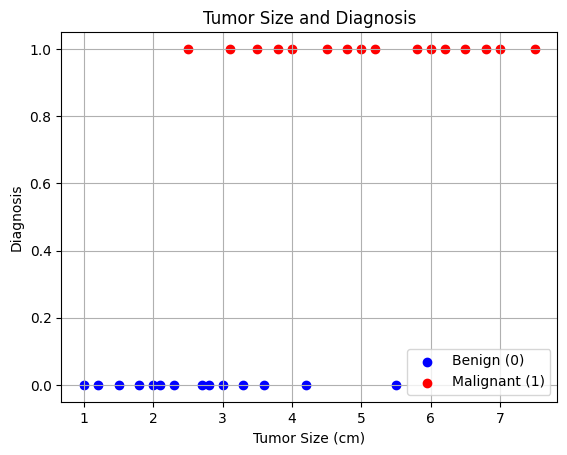

In [13]:
plt.scatter(tumor_size[diagnosis == 0], diagnosis[diagnosis == 0],
            color='blue', label='Benign (0)')
plt.scatter(tumor_size[diagnosis == 1], diagnosis[diagnosis == 1],
            color='red',  label='Malignant (1)')
plt.xlabel('Tumor Size (cm)')
plt.ylabel('Diagnosis')
plt.title('Tumor Size and Diagnosis')
plt.legend()
plt.grid(True)
plt.show()

### Split the Data

- `test_size=0.3` → 30% of the data goes to the test set
- `random_state=43` → fixes the random seed so the split is the same every time you run the notebook

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=43
)

print('Training samples:', len(X_train))
print('Test samples:    ', len(X_test))

Training samples: 21
Test samples:     9


### Fit the Model

In [15]:
model = LogisticRegression() #let's train the model using X_train and y_train
model.fit(X_train, y_train)

LogisticRegression()

### Make Predictions

`predict()` returns the predicted **class label** (0 or 1).

In [17]:
model.predict([[3.5]]) # size of the tumor is 3.5 cm

#[0]  --> model predicts that the tumor is benign (0) - not cancer ^.^


array([0])

In [18]:
model.predict([[6.5]]) #tumor size is 6.5 cm

#[1] means that the model's prediction is 1 (cancer/malignant)

array([1])

`predict_proba()` returns the predicted **probabilities** for both classes.  
The second value is the probability of class 1 (malignant).

In [19]:
model.predict_proba([[3.5]])

#result: the probability that the tumor size of 3.5 cm being benign: 55%
#        the prob......................................being malignant : 45%

array([[0.55080033, 0.44919967]])

### Plot the Logistic Regression Curve

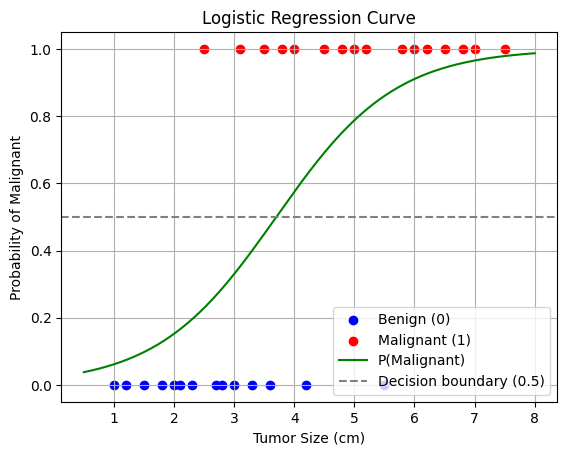

In [20]:
x_values = np.linspace(0.5, 8.0, 300).reshape(-1, 1)
p_values = model.predict_proba(x_values)[:, 1]

plt.scatter(tumor_size[diagnosis == 0], diagnosis[diagnosis == 0],
            color='blue', label='Benign (0)')
plt.scatter(tumor_size[diagnosis == 1], diagnosis[diagnosis == 1],
            color='red',  label='Malignant (1)')
plt.plot(x_values, p_values, color='green', label='P(Malignant)')
plt.axhline(y=0.5, linestyle='--', color='gray', label='Decision boundary (0.5)')
plt.xlabel('Tumor Size (cm)')
plt.ylabel('Probability of Malignant')
plt.title('Logistic Regression Curve')
plt.legend()
plt.grid(True)
plt.show()

---
## Decision Threshold

The default rule is:
- Predict **class 1** if predicted probability $\geq 0.5$
- Predict **class 0** if predicted probability $< 0.5$

This threshold of 0.5 is a choice — not a fixed rule.

In medicine, a **false negative** (missing a real cancer) may be far more serious than a **false positive** (unnecessary follow-up).  
In that case, we might lower the threshold to 0.3 so the model is more cautious.

This idea connects directly to later notebooks on:
- Confusion matrix
- Recall and Precision
- Optional ROC curve and AUC


---
## How Well Does Our Model Perform? Using the Test Set

After training the model on the training set, we use the **test set** to evaluate how well the model performs on unseen data.

Here we compare:

- `y_test`: the true labels in the test set
- `y_pred`: the predicted class labels
- `y_prob`: the predicted probabilities for class 1

One simple performance metric is **accuracy**.

$$
\text{Accuracy} = \frac{\text{number of correct predictions}}{\text{total number of predictions}}
$$

In later notebooks, we will study other performance metrics in more detail, such as the confusion matrix, recall, precision, and F1 score.


In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("True labels:          ", y_test)
print("Predicted labels:     ", y_pred)
print("Predicted probabilities:", y_prob.round(2))


True labels:           [1 0 1 0 1 0 0 1 0]
Predicted labels:      [1 0 0 0 0 0 0 1 0]
Predicted probabilities: [0.93 0.4  0.45 0.2  0.23 0.27 0.33 0.79 0.29]


---
### Simple Accuracy Calculation

We can calculate accuracy by comparing `y_test` and `y_pred` element by element.

In the test-set results above, **7** of the **9** predicted labels match the true labels.

So the accuracy is:

$$
\text{Accuracy} = \frac{7}{9} \approx 0.778
$$

So the model correctly classifies about **77.8%** of the tumors in the test set.


In [24]:
matches = (y_test == y_pred)

print (matches)

print("Matches (True = correct, False = wrong):", matches)
print("Number of correct predictions:", matches.sum())
print("Total number of test cases:   ", len(y_test))
print("Accuracy =", round(matches.sum() / len(y_test), 3))
print()
print("Example of a wrong prediction from the test set:")
print("3rd true label:      ", y_test[2])
print("3rd predicted label: ", y_pred[2])


[ True  True False  True False  True  True  True  True]
Matches (True = correct, False = wrong): [ True  True False  True False  True  True  True  True]
Number of correct predictions: 7
Total number of test cases:    9
Accuracy = 0.778

Example of a wrong prediction from the test set:
3rd true label:       1
3rd predicted label:  0


The **3rd element** is a wrong prediction.

The true label is **1** (malignant), but the predicted label is **0** (benign).  
So this is an incorrect prediction.

In later notebooks, we will talk more about these kinds of wrong predictions when we study:

- confusion matrix
- recall
- precision
- F1 score


We will also discuss why **test performance** is more meaningful than training performance, and how that connects to underfitting and overfitting.

### Effect of Lowering the Decision Threshold (using the current tumor dataset)

The default decision threshold in logistic regression is **0.5**.

That means:
- if `P(malignant) >= 0.5`, the model predicts **malignant (class 1)**
- if `P(malignant) < 0.5`, the model predicts **benign (class 0)**

If we lower the threshold from **0.5** to **0.3**, the model becomes **more likely to predict malignant**.

In this current fitted model, the boundary changes like this:
- threshold **0.5**  → boundary at about **3.70 cm**
- threshold **0.3**  → boundary at about **2.86 cm**

So tumors with sizes between about **2.86 cm** and **3.70 cm** change from **benign** to **malignant** when the threshold is lowered.

For example, in this current model, a tumor of **3.5 cm** has:
- `P(malignant) ≈ 0.45`
- `P(benign) ≈ 0.55`

So:
- at threshold **0.5**, the model predicts **benign**
- at threshold **0.3**, the model predicts **malignant**

We will study this idea more carefully in later notebooks when we discuss:
- confusion matrix
- recall and precision
- optional ROC curve and AUC


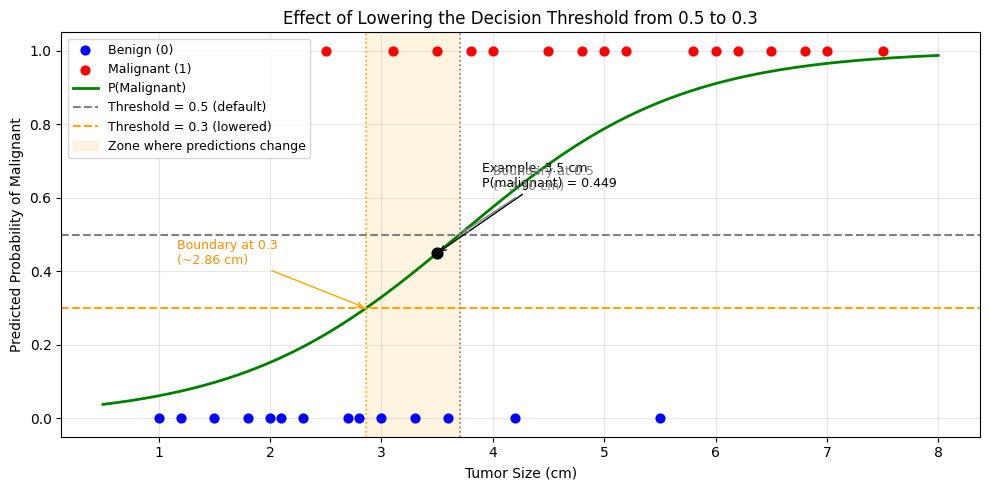

Current model boundary at threshold 0.5: 3.70 cm
Current model boundary at threshold 0.3: 2.86 cm

Example tumor from the current model:
  tumor size = 3.5 cm
  P(malignant) = 0.449
  P(benign)    = 0.551

Prediction at threshold 0.5: 0  (benign)
Prediction at threshold 0.3: 1  (malignant)


In [25]:
# Run this cell to see the effect of lowering the decision threshold
# using the CURRENT dataset and the CURRENT fitted logistic regression model.

import numpy as np
import matplotlib.pyplot as plt

# Create x-values for the logistic curve
x_range = np.linspace(0.5, 8.0, 300).reshape(-1, 1)
p_range = model.predict_proba(x_range)[:, 1]

# Get the learned parameters from the CURRENT model
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

# Boundary formula:
# p = threshold  -->  log(threshold / (1 - threshold)) = beta_0 + beta_1 * x
# so x = (log(threshold / (1 - threshold)) - beta_0) / beta_1

threshold_05 = 0.5
threshold_03 = 0.3

boundary_05 = (np.log(threshold_05 / (1 - threshold_05)) - beta_0) / beta_1
boundary_03 = (np.log(threshold_03 / (1 - threshold_03)) - beta_0) / beta_1

# Example tumor from the CURRENT dataset
example_x = 3.5
example_prob_malignant = model.predict_proba([[example_x]])[0][1]
example_prob_benign = 1 - example_prob_malignant

pred_at_05 = 1 if example_prob_malignant >= 0.5 else 0
pred_at_03 = 1 if example_prob_malignant >= 0.3 else 0

fig, ax = plt.subplots(figsize=(10, 5))

# Scatter plot of the current dataset
ax.scatter(
    tumor_size[diagnosis == 0],
    diagnosis[diagnosis == 0],
    color='blue',
    s=40,
    label='Benign (0)',
    zorder=5
)
ax.scatter(
    tumor_size[diagnosis == 1],
    diagnosis[diagnosis == 1],
    color='red',
    s=40,
    label='Malignant (1)',
    zorder=5
)

# Logistic curve
ax.plot(x_range, p_range, color='green', linewidth=2, label='P(Malignant)')

# Threshold lines
ax.axhline(y=0.5, linestyle='--', color='gray', linewidth=1.5,
           label='Threshold = 0.5 (default)')
ax.axhline(y=0.3, linestyle='--', color='orange', linewidth=1.5,
           label='Threshold = 0.3 (lowered)')

# Vertical boundary lines
ax.axvline(x=boundary_05, linestyle=':', color='gray', linewidth=1.2)
ax.axvline(x=boundary_03, linestyle=':', color='orange', linewidth=1.2)

# Shade the zone where predictions change
ax.axvspan(boundary_03, boundary_05, alpha=0.12, color='orange',
           label='Zone where predictions change')

# Highlight the example tumor
ax.scatter(example_x, example_prob_malignant, color='black', s=60, zorder=6)
ax.annotate(
    f'Example: 3.5 cm\nP(malignant) = {example_prob_malignant:.3f}',
    xy=(example_x, example_prob_malignant),
    xytext=(example_x + 0.4, example_prob_malignant + 0.18),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
    color='black'
)

# Boundary annotations
ax.annotate(
    f'Boundary at 0.5\n(~{boundary_05:.2f} cm)',
    xy=(boundary_05, 0.5),
    xytext=(boundary_05 + 0.3, 0.62),
    arrowprops=dict(arrowstyle='->', color='gray'),
    color='gray',
    fontsize=9
)

ax.annotate(
    f'Boundary at 0.3\n(~{boundary_03:.2f} cm)',
    xy=(boundary_03, 0.3),
    xytext=(boundary_03 - 1.7, 0.42),
    arrowprops=dict(arrowstyle='->', color='orange'),
    color='darkorange',
    fontsize=9
)

ax.set_xlabel('Tumor Size (cm)')
ax.set_ylabel('Predicted Probability of Malignant')
ax.set_title('Effect of Lowering the Decision Threshold from 0.5 to 0.3')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Current model boundary at threshold 0.5: {boundary_05:.2f} cm')
print(f'Current model boundary at threshold 0.3: {boundary_03:.2f} cm')
print()

print('Example tumor from the current model:')
print(f'  tumor size = {example_x:.1f} cm')
print(f'  P(malignant) = {example_prob_malignant:.3f}')
print(f'  P(benign)    = {example_prob_benign:.3f}')
print()

print(f'Prediction at threshold 0.5: {pred_at_05}  '
      f'({"malignant" if pred_at_05 == 1 else "benign"})')
print(f'Prediction at threshold 0.3: {pred_at_03}  '
      f'({"malignant" if pred_at_03 == 1 else "benign"})')


---
## Practice Problems

These short questions are simple, direct checks of the main ideas from this lecture.  
Try to answer each one before opening the answer.

---

### Question 1

What is the main reason we use logistic regression instead of linear regression for binary classification?

<details>
<summary>Answer</summary>

Because logistic regression gives an output between 0 and 1, so it can be interpreted as a probability.  
Linear regression can produce values below 0 or above 1.

</details>

---

### Question 2

In our tumor example, what does class **1** mean?

<details>
<summary>Answer</summary>

Class 1 means **malignant**.

</details>

---

### Question 3

What does logistic regression predict first?

- A class label directly  
- A probability

<details>
<summary>Answer</summary>

A probability.

</details>

---

### Question 4

Why is the sigmoid function useful in logistic regression?

<details>
<summary>Answer</summary>

Because it converts any real number into a value between 0 and 1, so the output can be used as a probability.

</details>

---

### Question 5

If $z = 0$, what is the sigmoid output, and why is this value important?

<details>
<summary>Answer</summary>

The sigmoid output is **0.5**.  
This is important because 0.5 is the usual default decision threshold in binary classification.

</details>

---

### Question 6

If the predicted probability is **0.8** and the decision threshold is **0.5**, what class will be predicted?

<details>
<summary>Answer</summary>

Class 1.

</details>

---

### Question 7

What does `test_size=0.3` mean in `train_test_split()`?

<details>
<summary>Answer</summary>

It means 30% of the data is placed in the test set.

</details>

---

### Question 8

What does `random_state=43` do?

<details>
<summary>Answer</summary>

It makes the train/test split reproducible, so you get the same split each time you run the notebook.

</details>

---

### Question 9

Suppose `predict_proba([[4.0]]) = [[0.3, 0.7]]`.  
If the threshold is **0.5**, what class would be predicted, and what is the probability of malignancy?

<details>
<summary>Answer</summary>

The predicted class would be **class 1**, because 0.7 is greater than 0.5.  
The probability of malignancy is **0.7**.

</details>

---

### Question 10

If a tumor has a predicted probability of malignancy equal to **0.2**, is the model leaning toward **benign** or **malignant**?

<details>
<summary>Answer</summary>

Benign.

</details>


---
## Summary

In this lecture, we covered:

| Concept | Key Idea |
|---|---|
| Binary classification | Predicting one of two class labels |
| Why not linear regression | Predictions can go outside [0, 1] |
| Sigmoid function | Converts any real number to a probability between 0 and 1 |
| Logistic regression model | Learn $\beta_0$ and $\beta_1$ from training data, compute $z$, then apply the sigmoid to get $p$ |
| Binary cross-entropy | Loss function for logistic regression; larger loss when the model assigns low probability to the true class |
| Train / test split | 70% train, 30% test; in this introductory notebook we use scikit-learn's default settings instead of tuning hyperparameters |
| Decision threshold | Default is 0.5; can be adjusted depending on the cost of errors |

In later notebooks, we will use `y_test`, `y_pred`, and `y_prob` to formally evaluate the model with the confusion matrix, recall, precision, and optional ROC/AUC.
